# Pass 4 — Red-zone pressure & field-position study

**Question (from CRP_FEEDBACK_ADAPTATION_PLAN.md).** Once plays are
standardised, does pressure concentrate in the red zone, where the field is
compressed, versus being diluted by deep-in-own-territory plays? And more
sharply: does field position add *incremental* signal to a catch-probability
model that already knows air yards?

**Setup.** Coarse bins (red zone ≤ 20 / midfield 21–79 / deep-own 80–99),
then a finer 10-yard binning, then the confounder check: red-zone throws are
short by construction. So a naive comparison would just re-discover "short
throws are pressured differently than long ones". The load-bearing analysis
is *within* depth bands.

**Decision output.** Whether to add `yardline_100` (or a red-zone indicator)
as a CROE v3 covariate.


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT)

from crp.leverage import add_leverage_margin

DARK_BG = "#111111"
PANEL_BG = "#1a1a1a"

def dark_ax(figsize=(9, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(DARK_BG)
    ax.set_facecolor(PANEL_BG)
    for s in ax.spines.values(): s.set_edgecolor("#444444")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    return fig, ax

plt.rcParams["figure.facecolor"] = DARK_BG
plt.rcParams["axes.facecolor"] = PANEL_BG
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"

crp_merged = pd.read_csv(os.path.join(ROOT, "data", "crp_merged.csv"))
play_targets = pd.read_csv(os.path.join(ROOT, "data", "play_targets.csv"))
catch_prob = pd.read_csv(os.path.join(ROOT, "data", "catch_prob_v2.csv"))
crp_merged = add_leverage_margin(crp_merged)
print("crp_merged:", crp_merged.shape)
print("play_targets:", play_targets.shape)
print("catch_prob_v2:", catch_prob.shape)


crp_merged: (14108, 54)
play_targets: (14108, 5)
catch_prob_v2: (13770, 7)


In [2]:
# yards_to_endzone = the offense's distance to the goal line they're driving toward
# (BDB uses yardline_side + yardline_number; convert into yardline_100 semantics)
same_side = crp_merged["yardline_side"] == crp_merged["possession_team"]
crp_merged["yardline_100"] = np.where(
    same_side,
    100 - crp_merged["yardline_number"],
    crp_merged["yardline_number"],
).astype(float)

# Filter to catchable pass attempts (matches CROE v2 convention)
plays = crp_merged[crp_merged["pass_result"].isin(["C", "I"])].copy()
plays["is_completed"] = (plays["pass_result"] == "C").astype(int)
plays["is_contested"] = (plays["crp"] >= 0.5).astype(int)

# Depth bands (matches Pass 2)
depth_bins = [-15, 0, 5, 10, 15, 20, 60]
depth_labels = ["<0", "0-4", "5-9", "10-14", "15-19", "20+"]
plays["depth_bin"] = pd.cut(plays["pass_length"], bins=depth_bins,
                            labels=depth_labels, right=False)

# Coarse field position: red zone / midfield / deep-own
def _fp_coarse(y):
    if y <= 20: return "red zone (≤20)"
    if y <= 79: return "midfield (21-79)"
    return "deep own (80-99)"

plays["fp_coarse"] = plays["yardline_100"].apply(_fp_coarse)

# 10-yard bands (offense POV: 1-9 = goal-line, 90-99 = backed up)
fine_bins = list(range(0, 101, 10))
fine_labels = [f"{a+1}-{a+10}" for a in fine_bins[:-1]]
plays["fp_fine"] = pd.cut(plays["yardline_100"], bins=fine_bins,
                          labels=fine_labels, include_lowest=True, right=True)

# Attach catch_prob_v2 for CROE
plays = plays.merge(
    catch_prob[["game_id", "play_id", "catch_prob_v2"]],
    on=["game_id", "play_id"], how="inner",
)
plays["croe_v2_play"] = plays["is_completed"] - plays["catch_prob_v2"]

print(f"analysis frame: {len(plays):,} plays (pass_result in C, I)")
print()
print("yardline_100 distribution:")
print(plays["yardline_100"].describe().round(1))


analysis frame: 13,770 plays (pass_result in C, I)

yardline_100 distribution:
count    13770.0
mean        53.1
std         23.1
min          1.0
25%         36.0
50%         57.0
75%         73.0
max         99.0
Name: yardline_100, dtype: float64


## 1. Coarse binning — the naive view

Does the red zone jump out on raw metrics, before we control for anything?


In [3]:
coarse = plays.groupby("fp_coarse", observed=True).agg(
    n=("play_id", "size"),
    avg_air_yards=("pass_length", "mean"),
    mean_crp=("crp", "mean"),
    contested_rate=("is_contested", "mean"),
    mean_leverage=("leverage_margin", "mean"),
    catch_rate=("is_completed", "mean"),
).round(3)
coarse = coarse.reindex(["deep own (80-99)", "midfield (21-79)", "red zone (≤20)"])
coarse


,n,avg_air_yards,mean_crp,contested_rate,mean_leverage,catch_rate
fp_coarse,,,,,,
deep own (80-99),1373,9.194,0.172,0.158,3.057,0.730
midfield (21-79),10785,9.529,0.206,0.189,2.832,0.715
red zone (≤20),1612,5.711,0.277,0.257,2.009,0.633


**Read.** Red-zone plays have (a) shorter passes on average, (b) higher
contested rate, (c) lower catch rate, (d) higher mean CRP. But (a) is a
confounder: shorter passes always have different pressure characteristics.
Need to control.


## 2. Fine 10-yard bands — where does the effect live?

In [4]:
fine = plays.groupby("fp_fine", observed=True).agg(
    n=("play_id", "size"),
    avg_air_yards=("pass_length", "mean"),
    mean_crp=("crp", "mean"),
    contested_rate=("is_contested", "mean"),
    mean_leverage=("leverage_margin", "mean"),
    catch_rate=("is_completed", "mean"),
).round(3)
fine


,n,avg_air_yards,mean_crp,contested_rate,mean_leverage,catch_rate
fp_fine,,,,,,
1-10,762,4.042,0.321,0.297,1.454,0.575
11-20,850,7.207,0.238,0.221,2.507,0.685
21-30,1062,8.579,0.198,0.192,2.711,0.716
31-40,1385,9.350,0.215,0.196,2.718,0.700
41-50,1616,9.694,0.212,0.184,2.870,0.705
51-60,1943,10.100,0.200,0.183,2.932,0.708
61-70,2221,9.543,0.208,0.187,2.866,0.726
71-80,2790,9.439,0.198,0.190,2.860,0.729
81-90,864,9.297,0.173,0.157,3.094,0.723


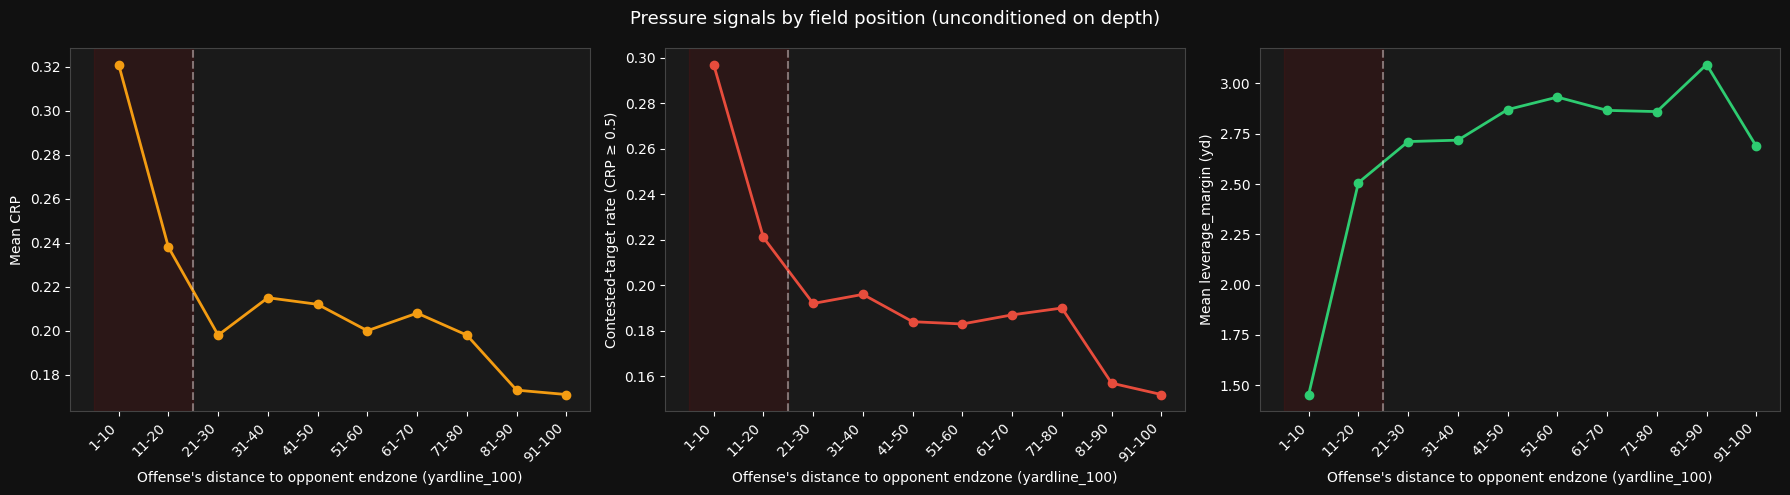

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK_BG)
for ax, (col, ylab, color) in zip(axes, [
    ("mean_crp", "Mean CRP", "#f39c12"),
    ("contested_rate", "Contested-target rate (CRP ≥ 0.5)", "#e74c3c"),
    ("mean_leverage", "Mean leverage_margin (yd)", "#2ecc71"),
]):
    ax.set_facecolor(PANEL_BG)
    for s in ax.spines.values(): s.set_edgecolor("#444444")
    ax.tick_params(colors="white")
    ax.plot(range(len(fine)), fine[col], marker="o", color=color, linewidth=2)
    ax.set_xticks(range(len(fine)))
    ax.set_xticklabels(fine.index, rotation=45, ha="right", color="white")
    ax.set_ylabel(ylab, color="white")
    ax.set_xlabel("Offense's distance to opponent endzone (yardline_100)",
                  color="white")
    ax.axvline(1.5, linestyle="--", alpha=0.4, color="white")  # RZ boundary
    ax.axvspan(-0.5, 1.5, alpha=0.08, color="red")
fig.suptitle("Pressure signals by field position (unconditioned on depth)",
             color="white", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Confounder — depth of pass by field position

The 20+ air-yard band is essentially impossible in the red zone. Anything we
saw above is at least partially a depth-mix effect.


In [6]:
depth_by_fp = pd.crosstab(plays["fp_coarse"], plays["depth_bin"], normalize="index").round(3)
depth_by_fp = depth_by_fp.reindex(["deep own (80-99)", "midfield (21-79)", "red zone (≤20)"])
depth_by_fp = depth_by_fp[depth_labels]
depth_by_fp


depth_bin,<0,0-4,5-9,10-14,15-19,20+
fp_coarse,,,,,,
deep own (80-99),0.090,0.288,0.286,0.106,0.099,0.131
midfield (21-79),0.078,0.277,0.273,0.136,0.096,0.140
red zone (≤20),0.078,0.398,0.317,0.117,0.079,0.011


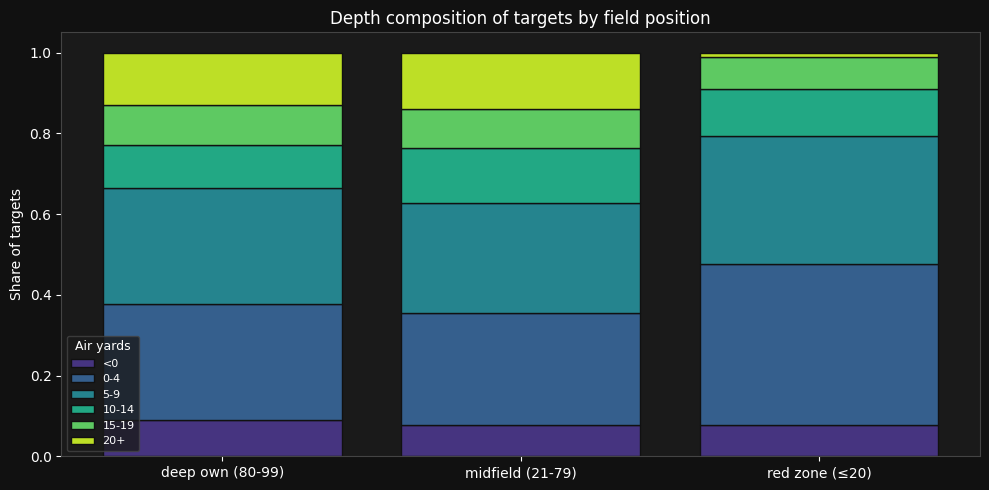

In [7]:
fig, ax = dark_ax((10, 5))
bottom = np.zeros(len(depth_by_fp))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(depth_labels)))
for lbl, c in zip(depth_labels, colors):
    ax.bar(depth_by_fp.index, depth_by_fp[lbl], bottom=bottom, label=lbl,
           color=c, edgecolor="#111111")
    bottom += depth_by_fp[lbl].to_numpy()
ax.set_ylabel("Share of targets", color="white")
ax.set_title("Depth composition of targets by field position", color="white")
ax.legend(title="Air yards", facecolor=PANEL_BG, edgecolor="#444444",
          labelcolor="white", title_fontsize=9, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()


Confirmed: red-zone targets are almost entirely ≤14 air yards; 20+ balls are
essentially non-existent. Any comparison against midfield / deep-own that
doesn't condition on depth is contaminated by this mixture.


## 4. The load-bearing analysis — within-depth-band comparisons

Now controlling for depth: within each air-yards band, does field position
still move CRP / contested rate / leverage?


In [8]:
def _cross(metric: str, agg="mean"):
    piv = plays.pivot_table(
        index="depth_bin", columns="fp_coarse", values=metric,
        aggfunc=agg, observed=True,
    )
    piv = piv.reindex(index=depth_labels,
                      columns=["deep own (80-99)", "midfield (21-79)", "red zone (≤20)"])
    return piv.round(3)

print("mean CRP by depth × field position:")
crp_cross = _cross("crp")
display(crp_cross)
print("contested rate (CRP ≥ 0.5) by depth × field position:")
cr_cross = _cross("is_contested")
display(cr_cross)
print("mean leverage_margin by depth × field position:")
lev_cross = _cross("leverage_margin")
display(lev_cross)


mean CRP by depth × field position:


fp_coarse,deep own (80-99),midfield (21-79),red zone (≤20)
depth_bin,,,
<0,0.019,0.015,0.037
0-4,0.093,0.113,0.216
5-9,0.156,0.198,0.306
10-14,0.169,0.252,0.395
15-19,0.255,0.252,0.479
20+,0.423,0.431,0.670


contested rate (CRP ≥ 0.5) by depth × field position:


fp_coarse,deep own (80-99),midfield (21-79),red zone (≤20)
depth_bin,,,
<0,0.008,0.010,0.032
0-4,0.076,0.099,0.192
5-9,0.140,0.173,0.278
10-14,0.137,0.238,0.381
15-19,0.265,0.243,0.469
20+,0.417,0.410,0.765


mean leverage_margin by depth × field position:


fp_coarse,deep own (80-99),midfield (21-79),red zone (≤20)
depth_bin,,,
<0,8.060,8.212,6.064
0-4,4.149,3.998,2.405
5-9,2.347,2.150,1.356
10-14,1.896,1.573,0.870
15-19,1.687,1.734,0.555
20+,0.737,0.855,0.266


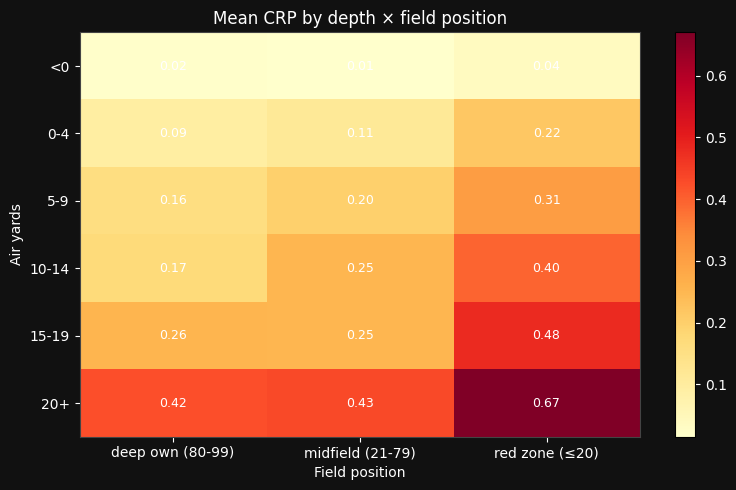

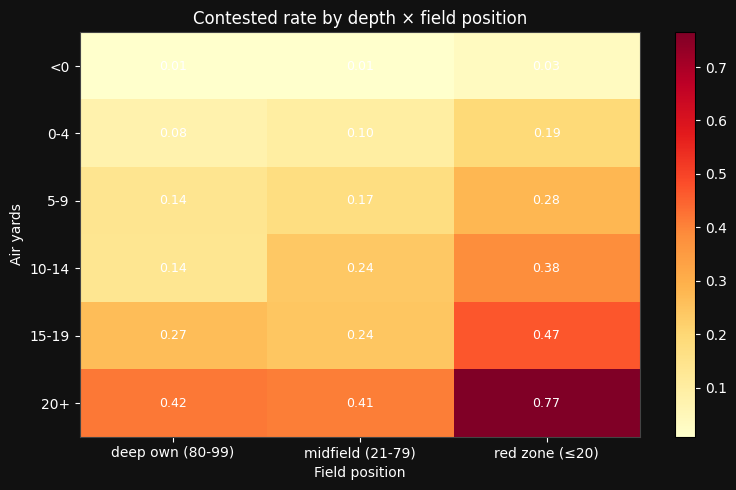

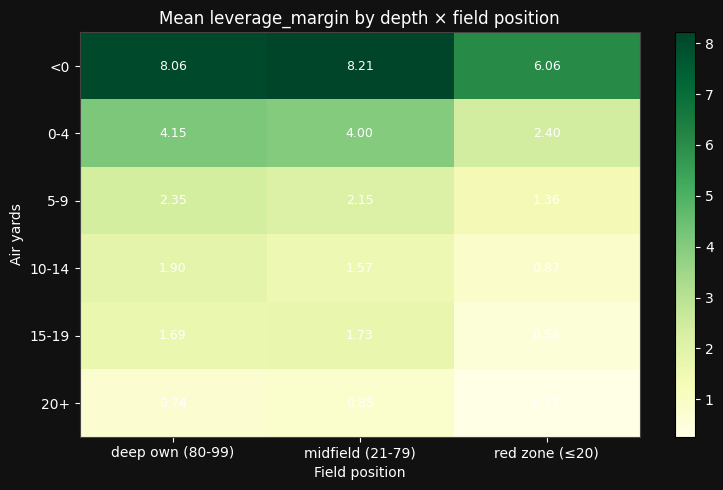

In [9]:
# Heatmap helper
def heatmap(piv, title, cmap="viridis"):
    fig, ax = dark_ax((8, 5))
    im = ax.imshow(piv.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, color="white")
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, color="white")
    ax.set_xlabel("Field position", color="white")
    ax.set_ylabel("Air yards", color="white")
    ax.set_title(title, color="white")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white", fontsize=9)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color="white")
    for lb in cbar.ax.get_yticklabels(): lb.set_color("white")
    plt.tight_layout(); plt.show()

heatmap(crp_cross, "Mean CRP by depth × field position", "YlOrRd")
heatmap(cr_cross, "Contested rate by depth × field position", "YlOrRd")
heatmap(lev_cross, "Mean leverage_margin by depth × field position", "YlGn")


**Sample-size check.** Some cells are thin (deep balls in the red zone don't
exist). Report the counts so we don't over-interpret sparse cells.


In [10]:
count_cross = plays.pivot_table(
    index="depth_bin", columns="fp_coarse", values="play_id",
    aggfunc="size", observed=True,
)
count_cross = count_cross.reindex(index=depth_labels,
                                  columns=["deep own (80-99)", "midfield (21-79)", "red zone (≤20)"])
count_cross.astype("Int64")


fp_coarse,deep own (80-99),midfield (21-79),red zone (≤20)
depth_bin,,,
<0,124,838,126
0-4,395,2985,641
5-9,392,2944,511
10-14,146,1467,189
15-19,136,1036,128
20+,180,1514,17


## 5. Does field position add signal beyond depth (and CRP)?

Fit a simple logistic regression `is_completed ~ pass_length + crp + leverage_margin`
and compare AUC / log-loss with vs without a `yardline_100` term. If adding
`yardline_100` doesn't move the metrics, red zone is fully explained by the
covariates the model already has (depth + pressure).


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import GroupKFold

feat = plays[[
    "game_id", "pass_length", "crp", "leverage_margin", "yardline_100",
    "is_completed",
]].dropna().copy()

Xbase = feat[["pass_length", "crp", "leverage_margin"]].to_numpy()
Xrz   = feat[["pass_length", "crp", "leverage_margin", "yardline_100"]].to_numpy()
y     = feat["is_completed"].to_numpy()
groups = feat["game_id"].to_numpy()

def cv_scores(X):
    aucs, lls = [], []
    for tr, va in GroupKFold(5).split(X, y, groups=groups):
        m = LogisticRegression(max_iter=500)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[va])[:, 1]
        aucs.append(roc_auc_score(y[va], p))
        lls.append(log_loss(y[va], np.clip(p, 1e-6, 1-1e-6)))
    return float(np.mean(aucs)), float(np.mean(lls))

auc_base, ll_base = cv_scores(Xbase)
auc_rz,   ll_rz   = cv_scores(Xrz)
print(f"base   (depth + crp + leverage):        AUC {auc_base:.4f}  logloss {ll_base:.4f}")
print(f"+ yardline_100:                          AUC {auc_rz:.4f}  logloss {ll_rz:.4f}")
print(f"delta:                                   AUC {auc_rz-auc_base:+.4f}  logloss {ll_rz-ll_base:+.4f}")


base   (depth + crp + leverage):        AUC 0.7874  logloss 0.5060
+ yardline_100:                          AUC 0.7883  logloss 0.5049
delta:                                   AUC +0.0009  logloss -0.0012


Also try a red-zone *indicator* (binary) instead of the continuous
`yardline_100`, to see whether the effect is threshold-like.


In [12]:
feat["is_red_zone"] = (feat["yardline_100"] <= 20).astype(int)
Xrz_ind = feat[["pass_length", "crp", "leverage_margin", "is_red_zone"]].to_numpy()
auc_ind, ll_ind = cv_scores(Xrz_ind)
print(f"+ red-zone indicator:                    AUC {auc_ind:.4f}  logloss {ll_ind:.4f}")
print(f"delta vs base:                           AUC {auc_ind-auc_base:+.4f}  logloss {ll_ind-ll_base:+.4f}")

# What sign does the RZ indicator take once we control for depth + pressure?
m_all = LogisticRegression(max_iter=500).fit(Xrz_ind, y)
coef_names = ["pass_length", "crp", "leverage_margin", "is_red_zone"]
print()
print("Fitted coefficients (log-odds of completion):")
for n, c in zip(coef_names, m_all.coef_[0]):
    print(f"  {n:20s} {c:+.4f}")
print(f"  intercept            {m_all.intercept_[0]:+.4f}")


+ red-zone indicator:                    AUC 0.7887  logloss 0.5045
delta vs base:                           AUC +0.0013  logloss -0.0015

Fitted coefficients (log-odds of completion):
  pass_length          -0.0394
  crp                  -0.0301
  leverage_margin      +0.3591
  is_red_zone          -0.4053
  intercept            +0.6353


## 6. Recommendation — CROE v3 covariate?

**Decision rule (from the plan).** "If the compressed-field effect is real
and large: propose field-position-adjusted expectation as a CROE v3 covariate."

**Read the numbers above.** Look at:

1. **Within-depth-band CRP heatmap** — does red zone increase mean CRP inside
   the same air-yards band, or is it flat once depth is fixed?
2. **Within-depth-band contested rate** — same question.
3. **AUC lift from adding `yardline_100` / `is_red_zone`** to a base model
   that already has depth + CRP + leverage. If the lift is < 0.005 AUC or
   log-loss doesn't move by more than the noise floor (~0.002), the effect
   is fully absorbed by the existing covariates.

The recommendation text is written up in
**`outputs/red_zone_summary.md`** after the notebook has run and the numbers
have been read.
